# 02 - Classificação: Regressão Logística, LDA, QDA e KNN

## 1. Por que não usar Regressão Linear comum (OLS) para Classificação?

Em problemas de **Classificação**, a variável resposta ($Y$) é categórica (ex.: $Y=1$ para caloteiro/inadimplente e $Y=0$ para adimplente/bom pagador).

Se tentarmos ajustar uma reta de regressão linear comum ($Y = \beta_0 + \beta_1 X$):
1. **Previsões sem sentido:** Para valores muito baixos de $X$, a reta cospe números negativos (ex.: $-0{,}20$). Para valores altos, cospe valores acima de $100\%$ (ex.: $1{,}35$). Na prática, uma probabilidade **só pode existir entre $0$ e $1$ ($0\%$ e $100\%$)**.
2. **Variância dos erros não constante:** Como os pontos reais são apenas $0$ ou $1$, os resíduos nunca formam uma distribuição normal homogênea (violação de homocedasticidade).

---

## 2. A Solução: A Função Sigmoide e a Regressão Logística

Em vez de tentar prever uma linha reta infinita, a Regressão Logística passa a conta da reta por uma função em formato de "S" chamada **Função Sigmoide (ou Logística)**. Ela funciona como um **esmagador universal**: pega qualquer número real de $-\infty$ a $+\infty$ e comprime obrigatoriamente para a faixa de $(0, 1)$:

$$p(X) = P(Y=1 \mid X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

---

### O que é a letra "e" e de onde ela vem?

A letra **$e$** na fórmula não é uma incógnita ou variável; ela é uma **constante matemática fixa**, exatamente como o número Pi ($\pi \approx 3{,}1415$). 

* O nome dela é **Número de Euler** (ou base dos logaritmos naturais).
* O seu valor numérico aproximado é:
  $$e \approx 2{,}71828$$
* **Como calcular $e^z$ na prática?**
  Significa pegar esse número $2{,}71828$ e elevar ao expoente $z$ (o resultado da reta):
  * Se $z = 0$: $e^0 = 1$ (qualquer base elevada a zero resulta em $1$).
  * Se $z = 1$: $e^1 \approx 2{,}718$.
  * Se $z = 0{,}5$: $e^{0{,}5} = \sqrt{2{,}71828} \approx 1{,}6487$.
  * Se $z$ for negativo (ex.: $z = -5$): $e^{-5} = \frac{1}{e^5} = \frac{1}{2{,}71828^5} = \frac{1}{148{,}41} \approx 0{,}0067$.

> Em linguagens como Python ou em calculadoras, basta usar a função `np.exp(z)` ou a tecla `exp`.

---

### Para que serve a Sigmoide? (A Intuição da Curva em S)

A sigmoide garante que o resultado seja sempre uma probabilidade válida:
* Se a conta da reta der um valor muito negativo ($z \to -\infty$): $e^z \to 0$, logo $p(X) \to \mathbf{0}$ ($0\%$ de probabilidade).
* Se a conta da reta der exatamente zero ($z = 0$): $p(X) = \frac{1}{1 + e^0} = \frac{1}{1 + 1} = \frac{1}{2} = \mathbf{0{,}5}$ ($50\%$ de probabilidade / ponto de corte neutro).
* Se a conta da reta der um valor muito positivo ($z \to +\infty$): $p(X) \to \mathbf{1}$ ($100\%$ de probabilidade).

---

### Exemplo Prático com Números: Calculando na mão passo a passo

Suponha que um modelo treinado aprendeu os seguintes parâmetros para prever inadimplência pelo saldo (`balance`):
* $\beta_0 = -10{,}5$ (intercepto fixo)
* $\beta_1 = 0{,}0055$ (peso por dólar de dívida)

#### Caso 1: Cliente A (Saldo baixo: $X = \$1.000$)
1. **Passo 1 (Cálculo da reta linear $z$):**
   $$z = \beta_0 + \beta_1 X = -10{,}5 + (0{,}0055 \times 1000) = -10{,}5 + 5{,}5 = -5{,}0$$
2. **Passo 2 (Cálculo da exponencial $e^z$ com o número de Euler):**
   $$e^{-5{,}0} = 2{,}71828^{-5} \approx 0{,}006737$$
3. **Passo 3 (Aplicação na fórmula da Sigmoide):**
   $$p(X) = \frac{e^z}{1 + e^z} = \frac{0{,}006737}{1 + 0{,}006737} = \frac{0{,}006737}{1{,}006737} \approx \mathbf{0{,}0067} \quad (\mathbf{0{,}67\%} \text{ de risco})$$
   *Conclusão:* Como o saldo é baixo, o risco de inadimplência é desprezível (menor que $1\%$).

#### Caso 2: Cliente B (Saldo alto: $X = \$2.000$)
1. **Passo 1 (Cálculo da reta linear $z$):**
   $$z = \beta_0 + \beta_1 X = -10{,}5 + (0{,}0055 \times 2000) = -10{,}5 + 11{,}0 = +0{,}5$$
2. **Passo 2 (Cálculo da exponencial $e^z$ com o número de Euler):**
   $$e^{+0{,}5} = 2{,}71828^{0{,}5} \approx 1{,}6487$$
3. **Passo 3 (Aplicação na fórmula da Sigmoide):**
   $$p(X) = \frac{e^z}{1 + e^z} = \frac{1{,}6487}{1 + 1{,}6487} = \frac{1{,}6487}{2{,}6487} \approx \mathbf{0{,}6225} \quad (\mathbf{62{,}25\%} \text{ de risco})$$
   *Conclusão:* Com a dívida acumulada em $\$2.000$, a probabilidade saltou para mais de $62\%$.

---

## 3. O que são Chances (*Odds*) e Razão de Chances (*Odds Ratio*)?

Em estatística e apostas, **Odds (Chances)** é a razão entre a probabilidade de o evento acontecer e a de não acontecer:

$$\text{Odds} = \frac{p(X)}{1 - p(X)}$$

Isolando a combinação linear na fórmula da sigmoide, chegamos ao **Logit** (o logaritmo natural das chances):

$$\log\left(\frac{p(X)}{1 - p(X)}\right) = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p$$

* **Interpretação do coeficiente $\beta_j$:** Um aumento de 1 unidade em $X_j$ multiplica as chances de calote por um fator de $e^{\beta_j}$ (a **Razão de Chances / Odds Ratio**).

In [1]:
# Bibliotecas numéricas e tabulares
from pathlib import Path
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels: coeficientes com erro padrão e p-valor (igual às tabelas do ISLP)
import statsmodels.api as sm

# Scikit-learn: modelos, pré-processamento, validação e métricas
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 4. Carregando os Dados: Dataset Default (ISLP)

O dataset **`Default`** contém dados de 10.000 clientes de cartão de crédito:
* **Alvo (`default`):** O cliente atrasou o pagamento (Yes/No)? (~3,3% são inadimplentes — classes desbalanceadas).
* **Preditores:**
  * `student`: É estudante (Yes/No)?
  * `balance`: Saldo médio devedor no cartão após a fatura.
  * `income`: Renda anual do cliente.

> **Ordem de carregamento:** pacote `ISLP` → cópia local `data/Default.csv` → download do repositório oficial (salvando a cópia local).
> Não há fallback com dados sintéticos: se os dados reais não estiverem disponíveis, o notebook falha de forma explícita,
> para que nenhuma conclusão seja tirada de dados simulados.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Default.csv"
# Funciona rodando a partir da raiz do repo ou de dentro de notebooks/
LOCAL_CANDIDATES = [Path("data/Default.csv"), Path("../data/Default.csv")]


def load_default() -> pd.DataFrame:
    try:
        from ISLP import load_data
        return load_data("Default")
    except ImportError:
        pass
    for path in LOCAL_CANDIDATES:
        if path.exists():
            return pd.read_csv(path)
    df = pd.read_csv(DATA_URL)  # levanta erro se não houver conexão
    target = LOCAL_CANDIDATES[1] if Path("../data").exists() else LOCAL_CANDIDATES[0]
    target.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(target, index=False)
    return df


Default = load_default().drop(columns=["Unnamed: 0"], errors="ignore")

# Codificação binária (0 e 1)
Default["default_num"] = (Default["default"] == "Yes").astype(int)
Default["student_num"] = (Default["student"] == "Yes").astype(int)

print(f"Tamanho do dataset: {Default.shape[0]} linhas e {Default.shape[1]} colunas")
print("Distribuição do alvo (Inadimplência):")
print(Default["default"].value_counts(normalize=True).map("{:.2%}".format))
Default.head()

Tamanho do dataset: 10000 linhas e 6 colunas
Distribuição do alvo (Inadimplência):
default
No     96.67%
Yes     3.33%
Name: proportion, dtype: object


,default,student,balance,income,default_num,student_num
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0
3,No,No,529.250605,35704.493935,0,0
4,No,No,785.655883,38463.495879,0,0


## 5. Como o modelo é treinado? (Máxima Verossimilhança)

Na Regressão Linear, minimizamos o erro de distância entre os pontos e a reta (RSS).
Na Regressão Logística, usamos **Máxima Verossimilhança (Maximum Likelihood Estimation - MLE)**.

### A Ideia Intuitiva:
O algoritmo procura os valores de $\beta_0, \beta_1$ que gerem probabilidades bem altas para quem realmente deu calote ($Y=1$) e probabilidades bem baixas para quem pagou em dia ($Y=0$):

$$\text{Verossimilhança } L(\boldsymbol{\beta}) = \prod_{\text{caloteiros}} p(x_i) \times \prod_{\text{bons pagadores}} (1 - p(x_i))$$

#### Exemplo Numérico Simples:
Suponha que temos 2 clientes no banco:
* **Cliente 1:** Deu calote real ($Y=1$).
* **Cliente 2:** Pagou em dia ($Y=0$).

Se o algoritmo testar uma curva com parâmetros que deem:
* $p(x_1) = 0{,}90$ (previu $90\%$ de calote para quem deu calote) $\rightarrow$ Acertou!
* $p(x_2) = 0{,}10$ (previu $10\%$ de calote para quem pagou em dia, logo $1 - 0{,}10 = 0{,}90$ de pagar) $\rightarrow$ Acertou!

A Verossimilhança é:
$$L = 0{,}90 \times (1 - 0{,}10) = 0{,}90 \times 0{,}90 = \mathbf{0{,}81}$$

Se ele testasse parâmetros ruins que dessem:
* $p(x_1) = 0{,}20$ e $p(x_2) = 0{,}80$, a conta seria:
$$L = 0{,}20 \times (1 - 0{,}80) = 0{,}20 \times 0{,}20 = \mathbf{0{,}04} \quad (valor baixo, modelo ruim)$$

> O computador utiliza otimizadores numéricos (como L-BFGS e Newton-Raphson) para achar automaticamente os betas que maximizam essa função.

### Implementação: Regressão Logística Simples (`balance`)

> **Sobre `penalty=None`:** o `LogisticRegression` do scikit-learn aplica regularização L2 **por padrão** (`C=1.0`).
> Para obter a estimativa clássica de **Máxima Verossimilhança** (a mesma do livro), desligamos a penalidade com `penalty=None`.
> Não existe "OLS" na regressão logística — o ajuste é sempre por MLE.

In [3]:
X_simple = Default[["balance"]]
y = Default["default_num"]

# Divisão treino/teste (75% / 25%) estratificada para manter ~3,3% de inadimplentes nos dois conjuntos
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# MLE puro (sem regularização)
simple_logit = LogisticRegression(penalty=None, max_iter=1000)
simple_logit.fit(X_train_s, y_train_s)

b0 = simple_logit.intercept_[0]
b1 = simple_logit.coef_[0][0]

print(f"Intercepto (beta_0): {b0:.4f}")
print(f"Coeficiente de saldo (beta_1): {b1:.6f}")
print(f"Multiplicador de chance (odds ratio) a cada +$100 no saldo: {np.exp(b1 * 100):.3f}x")

Intercepto (beta_0): -10.8065
Coeficiente de saldo (beta_1): 0.005613
Multiplicador de chance (odds ratio) a cada +$100 no saldo: 1.753x


**Interpretação:** cada \$100 a mais de saldo devedor multiplica as **chances** (*odds*) de inadimplência por ≈ 1,75.
Os valores batem com a Tabela 4.1 do ISLP ($\hat\beta_0 \approx -10{,}65$, $\hat\beta_1 \approx 0{,}0055$) — a pequena diferença vem de treinarmos apenas com 75% dos dados.

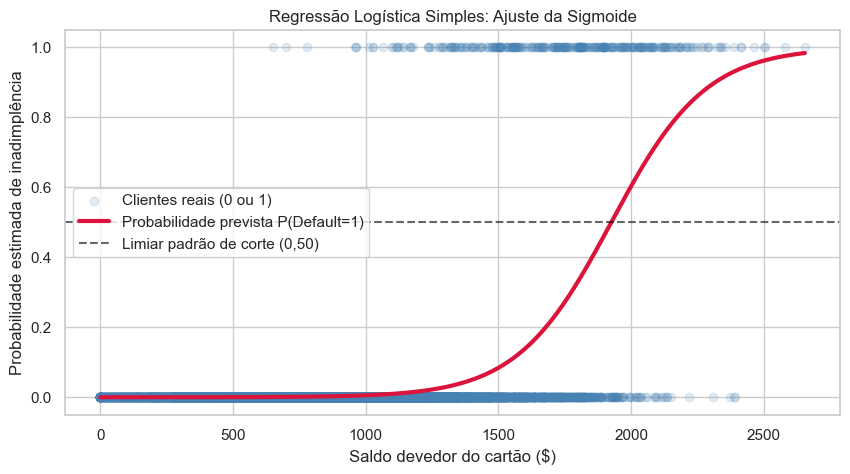

In [4]:
# Grade de valores para plotar a curva predita suave (DataFrame evita o warning de feature names)
bal_grid = pd.DataFrame(
    {"balance": np.linspace(Default["balance"].min(), Default["balance"].max(), 300)}
)
probs = simple_logit.predict_proba(bal_grid)[:, 1]

plt.figure(figsize=(10, 5))
plt.scatter(Default["balance"], Default["default_num"], alpha=0.15, color="steelblue", label="Clientes reais (0 ou 1)")
plt.plot(bal_grid["balance"], probs, color="crimson", linewidth=3, label="Probabilidade prevista P(Default=1)")
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6, label="Limiar padrão de corte (0,50)")
plt.xlabel("Saldo devedor do cartão ($)")
plt.ylabel("Probabilidade estimada de inadimplência")
plt.title("Regressão Logística Simples: Ajuste da Sigmoide")
plt.legend()
plt.show()

## 6. Avaliação e o Impacto do Limiar de Decisão (*Threshold*)

O modelo logístico gera **probabilidades contínuas** (ex.: $0{,}12$, $0{,}48$, $0{,}76$).
Para tomar uma ação (ex.: bloquear cartão ou enviar para cobrança), precisamos definir uma linha de corte (limiar / *threshold*):

$$\text{Se } P(Y=1) \ge \text{Threshold} \rightarrow \text{Classifica como Caloteiro (1)}$$

### As 4 Possibilidades da Matriz de Confusão:
| | Previu: Não Inadimplente (0) | Previu: Inadimplente (1) |
| :--- | :---: | :---: |
| **Real: Não Inadimplente (0)** | **Verdadeiro Negativo (VN)** | **Falso Positivo (FP)** (Alarme Falso) |
| **Real: Inadimplente (1)** | **Falso Negativo (FN)** (Prejuízo!) | **Verdadeiro Positivo (VP)** (Detecção Correta) |

---

### Fórmulas Explicadas com Números:
Suponha uma matriz de teste com os seguintes resultados:
* $VN = 2400$, $FP = 15$
* $FN = 55$, $VP = 30$

1. **Acurácia (Total de Acertos / Total Geral):**
   $$\text{Acurácia} = \frac{VN + VP}{\text{Total}} = \frac{2400 + 30}{2500} = \frac{2430}{2500} = \mathbf{97{,}2\%}$$
   > *Atenção:* Parece ótimo, mas repare que dos 85 caloteiros reais ($55 + 30$), o banco deixou passar 55 caloteiros ilesos!

2. **Recall / Sensibilidade (Quantos caloteiros reais nós pegamos?):**
   $$\text{Recall} = \frac{VP}{VP + FN} = \frac{30}{30 + 55} = \frac{30}{85} = \mathbf{35{,}3\%}$$
   > O modelo deixou escapar quase $65\%$ dos inadimplentes!

3. **Precisão (Quando o modelo tocou o alarme, ele estava certo?):**
   $$\text{Precisão} = \frac{VP}{VP + FP} = \frac{30}{30 + 15} = \frac{30}{45} = \mathbf{66{,}7\%}$$

---

### A Decisão de Negócio: Mudando o Limiar de 0.50 para 0.20
Se baixarmos a régua de corte para $0{,}20$ ($20\%$ de probabilidade):
* Fica mais fácil classificar como risco $\rightarrow$ **Recall dispara (capturamos muito mais devedores)**.
* Em troca, aumentam os alarmes falsos (bloquear cartões de alguns clientes bons).

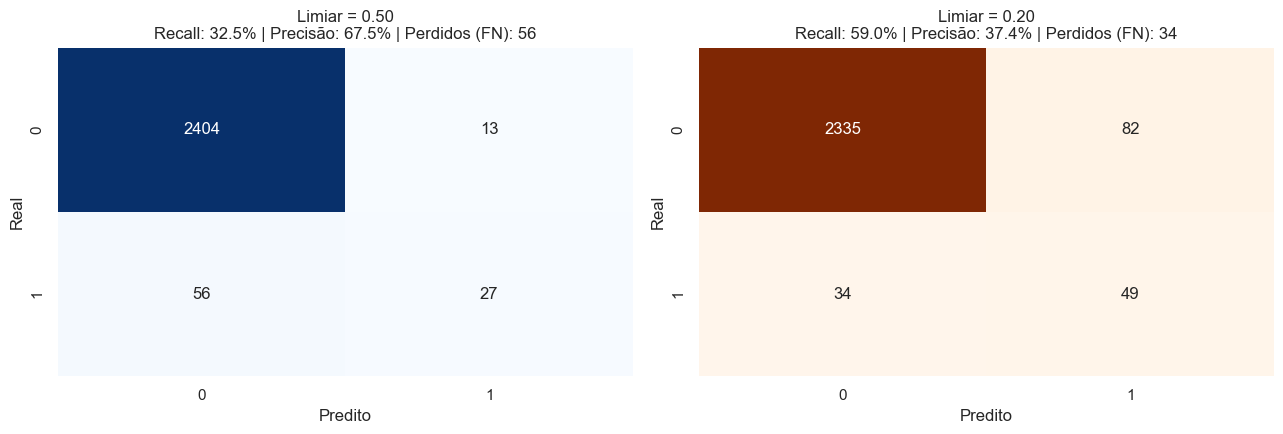

In [5]:
y_prob_s = simple_logit.predict_proba(X_test_s)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, thr, cmap in zip(axes, [0.50, 0.20], ["Blues", "Oranges"]):
    y_pred = (y_prob_s >= thr).astype(int)
    cm = confusion_matrix(y_test_s, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax, cbar=False)
    ax.set_title(
        f"Limiar = {thr:.2f}\n"
        f"Recall: {recall_score(y_test_s, y_pred):.1%} | "
        f"Precisão: {precision_score(y_test_s, y_pred):.1%} | "
        f"Perdidos (FN): {cm[1, 0]}"
    )
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Leitura dos resultados (conjunto de teste, 2.500 clientes / 83 inadimplentes):**

| Limiar | VN | FP | FN | VP | Recall | Precisão |
| :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 0,50 | 2404 | 13 | 56 | 27 | 32,5% | 67,5% |
| 0,20 | 2335 | 82 | 34 | 49 | 59,0% | 37,4% |

* Baixar o limiar para 0,20 **quase dobra o recall** (27 → 49 calotes capturados), ao custo de 69 alarmes falsos a mais.
* A precisão cai de 67% para 37%: de cada 8 clientes bloqueados, ~5 eram bons pagadores. Se isso é aceitável depende da **matriz de custos** do negócio.

## 7. O que é a Curva ROC e a Métrica AUC?

Em vez de avaliar apenas um limiar fixo ($0{,}50$ ou $0{,}20$), a **Curva ROC** testa **todos os limiares possíveis** de $0\%$ a $100\%$ e desenha um gráfico:
* **Eixo Y (Benefício):** Taxa de Verdadeiro Positivo (Recall = quantos caloteiros pegamos).
* **Eixo X (Custo):** Taxa de Falso Positivo (quantos bons pagadores acusamos por engano).

### O que significa a área sob a curva (AUC - Area Under Curve)?
* $\text{AUC} = 0{,}50$: O modelo é equivalente a jogar uma moeda no ar (aleatório).
* $\text{AUC} = 1{,}00$: O modelo é perfeito e separa perfeitamente bons de maus pagadores em qualquer nível.
* $\text{AUC} \ge 0{,}90$: Excelente capacidade discriminativa!

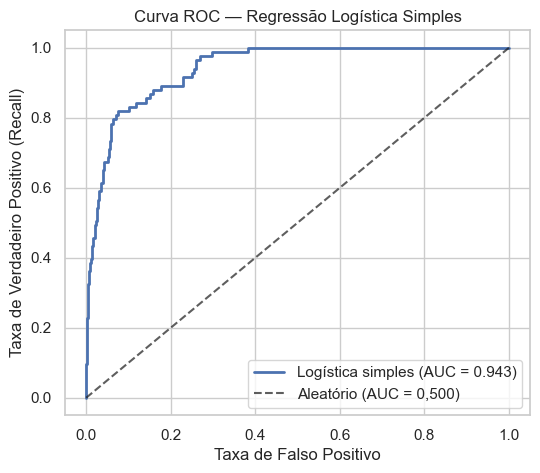

In [6]:
fpr, tpr, _ = roc_curve(y_test_s, y_prob_s)
auc_simple = roc_auc_score(y_test_s, y_prob_s)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"Logística simples (AUC = {auc_simple:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Aleatório (AUC = 0,500)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo (Recall)")
plt.title("Curva ROC — Regressão Logística Simples")
plt.legend()
plt.show()

## 8. O Paradoxo do Estudante (Paradoxo de Simpson)

Vamos **demonstrar** (e não apenas afirmar) o paradoxo, ajustando dois modelos com `statsmodels` na base completa — como no ISLP (Tabelas 4.2 e 4.3):
1. Logística **univariada** com `student`.
2. Logística **múltipla** com `balance`, `income` e `student`.

In [7]:
# 1) Modelo univariado: default ~ student
logit_uni = sm.Logit(y, sm.add_constant(Default[["student_num"]])).fit(disp=0)

# 2) Modelo múltiplo: default ~ balance + income + student
features = ["balance", "income", "student_num"]
logit_multi_sm = sm.Logit(y, sm.add_constant(Default[features])).fit(disp=0)

comparativo = pd.DataFrame({
    "Coef. student (univariado)": [logit_uni.params["student_num"]],
    "Coef. student (múltiplo)": [logit_multi_sm.params["student_num"]],
}, index=["student_num"])
display(comparativo.round(4))

tabela = logit_multi_sm.summary2().tables[1][["Coef.", "Std.Err.", "z", "P>|z|"]]
tabela["Odds Ratio exp(β)"] = np.exp(tabela["Coef."])
tabela.round(6)

,Coef. student (univariado),Coef. student (múltiplo)
student_num,0.4049,-0.6468


,Coef.,Std.Err.,z,P>|z|,Odds Ratio exp(β)
const,-10.869045,0.492273,-22.079320,0.000000,0.000019
balance,0.005737,0.000232,24.736506,0.000000,1.005753
income,0.000003,0.000008,0.369808,0.711525,1.000003
student_num,-0.646776,0.236257,-2.737595,0.006189,0.523732


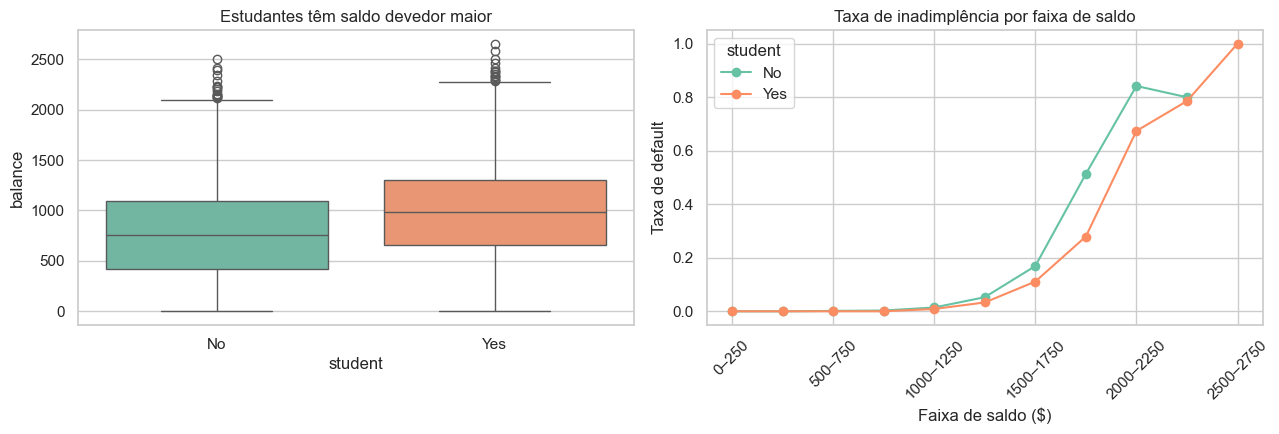

         balance     income  default_num
student                                 
No       771.770  40011.953        0.029
Yes      987.818  17950.231        0.043


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Estudantes carregam mais saldo
sns.boxplot(data=Default, x="student", y="balance", hue="student", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Estudantes têm saldo devedor maior")

# (b) Para o MESMO saldo, a taxa de inadimplência do estudante é menor
bins = pd.cut(Default["balance"], bins=np.arange(0, 2900, 250))
taxa = Default.groupby([bins, "student"], observed=True)["default_num"].mean().unstack()
taxa.index = [f"{int(i.left)}–{int(i.right)}" for i in taxa.index]
taxa.plot(marker="o", ax=axes[1], color=sns.color_palette("Set2")[:2])
axes[1].set_title("Taxa de inadimplência por faixa de saldo")
axes[1].set_xlabel("Faixa de saldo ($)")
axes[1].set_ylabel("Taxa de default")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(Default.groupby("student")[["balance", "income", "default_num"]].mean().round(3))

### Por que o coeficiente de `student` mudou de sinal?

* **Univariado:** $\hat\beta_{student} \approx +0{,}40$ → no agregado, estudantes inadimplem **mais** (≈ 4,3% vs 2,9%).
* **Múltiplo:** $\hat\beta_{student} \approx -0{,}65$ (p ≈ 0,006) → **para o mesmo saldo e renda**, ser estudante **reduz** as chances de calote ($e^{-0{,}65} \approx 0{,}52$, cerca de metade).
* **Mecanismo:** estudantes carregam saldos maiores (≈ \$988 vs \$772), e `balance` é o principal driver de risco. O efeito positivo no modelo univariado é, na verdade, efeito do saldo "vazando" para a variável `student` (**confundimento**).
* **`income` não é significativa** no modelo múltiplo (p ≈ 0,71): uma vez conhecidos o saldo e o status de estudante, a renda praticamente não acrescenta informação.

> Esse é o **Paradoxo de Simpson**: olhar uma variável isolada pode levar à conclusão oposta à obtida quando se controla pelos confundidores.

## 8. Comparativo de Modelos: Regressão Logística vs. LDA vs. QDA vs. KNN

O livro ISLP compara quatro famílias clássicas de algoritmos:

1. **Regressão Logística Múltipla:** Modela diretamente a probabilidade via combinação linear sem assumir que os dados vêm de uma distribuição normal.
2. **LDA (Análise Discriminante Linear):** Modela a distribuição dos preditores assumindo que cada classe segue uma distribuição Normal (Gaussiana) com a **mesma matriz de covariância** (mesma variabilidade). Gera fronteiras lineares.
3. **QDA (Análise Discriminante Quadrática):** Mais flexível que o LDA. Assume que cada classe tem sua **própria matriz de covariância**, permitindo curvas e fronteiras parabólicas/curvas.
4. **KNN (K-Vizinhos Mais Próximos):** Abordagem **não paramétrica**. Não assume nenhuma fórmula matemática; apenas olha para os $K$ clientes mais próximos na base histórica e faz uma votação.

### Cuidados metodológicos neste comparativo

1. **Escala importa para o KNN.** A distância euclidiana é dominada pela variável de maior magnitude: `income` (dezenas de milhares) "apaga" `balance` (centenas) e `student` (0/1). Por isso comparamos KNN **sem** e **com** `StandardScaler`.
2. **K pequeno gera probabilidades "em degraus".** Com $K=10$, `predict_proba` só assume 11 valores (0/10, 1/10, …), o que prejudica o ranqueamento (AUC). Testamos também $K=50$.
3. **Validação cruzada.** Além do conjunto de teste, reportamos a **ROC-AUC média ± desvio em 5 folds** estratificados no treino — uma única divisão treino/teste é ruidosa.
4. **Logística com escala + `penalty=None`.** Padronizar não altera as previsões da logística sem penalidade, mas ajuda o otimizador a convergir.

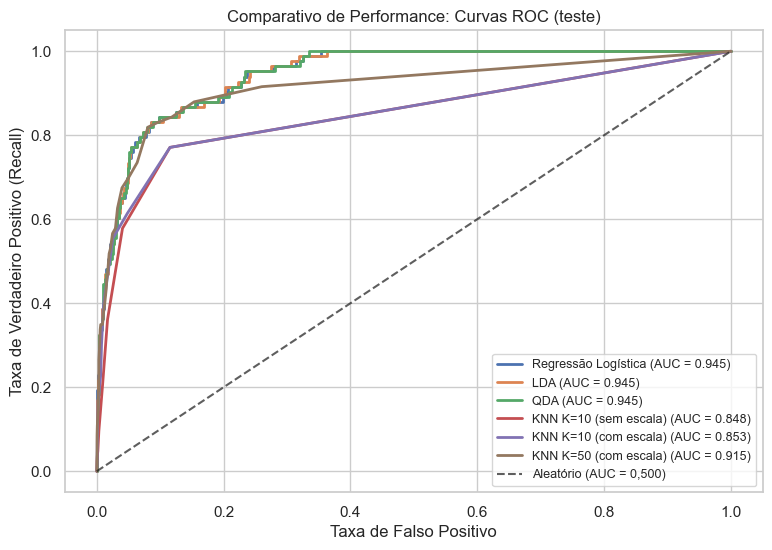

,ROC-AUC CV (média),ROC-AUC CV (desvio),ROC-AUC teste,"Recall (0,5)","Precisão (0,5)",Acurácia
Modelo,,,,,,
Regressão Logística,0.950,0.007,0.945,0.325,0.692,0.973
LDA,0.950,0.006,0.945,0.253,0.750,0.972
QDA,0.949,0.006,0.945,0.301,0.735,0.973
KNN K=10 (sem escala),0.825,0.036,0.848,0.048,0.500,0.967
KNN K=10 (com escala),0.843,0.027,0.853,0.301,0.581,0.970
KNN K=50 (com escala),0.931,0.014,0.915,0.241,0.714,0.972


In [9]:
X_multi = Default[features]
y_multi = Default["default_num"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=RANDOM_STATE, stratify=y_multi
)

models = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(penalty=None)),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "KNN K=10 (sem escala)": KNeighborsClassifier(n_neighbors=10),
    "KNN K=10 (com escala)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10)),
    "KNN K=50 (com escala)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=50)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

plt.figure(figsize=(9, 6))
for name, clf in models.items():
    cv_auc = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring="roc_auc")
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = clf.predict(X_te)
    auc = roc_auc_score(y_te, y_prob)

    rows.append({
        "Modelo": name,
        "ROC-AUC CV (média)": cv_auc.mean(),
        "ROC-AUC CV (desvio)": cv_auc.std(),
        "ROC-AUC teste": auc,
        "Recall (0,5)": recall_score(y_te, y_pred),
        "Precisão (0,5)": precision_score(y_te, y_pred, zero_division=0),
        "Acurácia": accuracy_score(y_te, y_pred),
    })
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.7, label="Aleatório (AUC = 0,500)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo (Recall)")
plt.title("Comparativo de Performance: Curvas ROC (teste)")
plt.legend(fontsize=9)
plt.show()

results = pd.DataFrame(rows).set_index("Modelo")
results.style.format("{:.3f}")

### Leitura do comparativo

* **Logística, LDA e QDA empatam** (AUC ≈ 0,95 em CV e no teste; diferenças < 1 desvio-padrão). A fronteira de decisão real deste problema é praticamente linear em `balance`, então a flexibilidade extra do QDA não traz ganho.
* **KNN sem escala é o pior** (AUC CV ≈ 0,82 e recall de ~5% no corte 0,5): a distância é dominada por `income`, justamente a variável **sem poder preditivo**.
* **Padronizar** melhora o KNN (recall 5% → 30%), e **aumentar K para 50** suaviza as probabilidades e leva a AUC para ≈ 0,93 — ainda abaixo dos modelos lineares.
* Portanto, a desvantagem do KNN aqui **não é "maldição da dimensionalidade"** (são só 3 preditores): ela vem de **escala** + **K pequeno** + um problema cuja estrutura é linear, cenário em que modelos paramétricos são mais eficientes.

## 9. Escolhendo o Limiar para o Modelo Final

Usando a **Regressão Logística múltipla**, avaliamos vários limiares no conjunto de teste:

In [10]:
final_model = models["Regressão Logística"]
y_prob_final = final_model.predict_proba(X_te)[:, 1]

linhas = []
for thr in [0.50, 0.30, 0.20, 0.10]:
    y_pred = (y_prob_final >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    linhas.append({
        "Limiar": thr, "VP (calotes pegos)": tp, "FN (calotes perdidos)": fn,
        "FP (alarmes falsos)": fp, "Recall": tp / (tp + fn), "Precisão": tp / (tp + fp),
    })
pd.DataFrame(linhas).set_index("Limiar").style.format({"Recall": "{:.1%}", "Precisão": "{:.1%}"})

,VP (calotes pegos),FN (calotes perdidos),FP (alarmes falsos),Recall,Precisão
Limiar,,,,,
0.500000,27,56,12,32.5%,69.2%
0.300000,43,40,46,51.8%,48.3%
0.200000,50,33,84,60.2%,37.3%
0.100000,65,18,154,78.3%,29.7%


## 10. Resumo Executivo para Tomada de Decisão (Visão de Negócio)

* **Objetivo:** Estimar a probabilidade de inadimplência no cartão para política de crédito e cobrança preventiva.
* **Driver de risco:** O saldo devedor (`balance`) domina o risco — cada +\$100 multiplica as chances de calote por ≈ 1,75. A renda (`income`) **não é estatisticamente significativa** quando o saldo é conhecido.
* **Estudantes:** No agregado parecem mais arriscados, mas **para o mesmo saldo** têm cerca de metade das chances de calote (Paradoxo de Simpson). Usar `student` isoladamente em uma política de crédito levaria a uma decisão errada.
* **Comparação técnica:** Logística, LDA e QDA empatam (ROC-AUC ≈ 0,95, validado em 5 folds). O KNN só se aproxima após padronização e K maior (≈ 0,93). Recomenda-se a **Regressão Logística** pela interpretabilidade (odds ratios) e simplicidade de produção.
* **Calibração do limiar:** O corte padrão 0,50 captura apenas ~33% dos inadimplentes. Reduzir para **0,20** eleva o recall para ~60% (precisão ~37%); para capturar ~78% é preciso descer a **0,10** (precisão ~30%). A escolha final deve vir da **razão entre o custo de um calote (FN) e o de bloquear um bom cliente (FP)**.
* **Limitações:** Apenas 3 preditores e ~330 eventos positivos; avaliar estabilidade temporal e calibração das probabilidades antes de uso em produção.